In [16]:
import pandas as pd
df = pd.read_csv('evaluation/fluency/fluency_scores_gpt2.csv')
df['raw'] = False
# df = df[df['perturbation'] != 'shuffle_nondeterministic']
# df2 = pd.read_csv('evaluation/fluency/fluency_scores_raw.csv')
# merge on row number
# df['row_number'] = df.index
# df2['row_number'] = df2.index
# df = df.merge(df2[['row_number', 'perplexity', 'slor', 'morcela', 'generation']], on='row_number', how='left', suffixes=('', '_raw'))
# df.drop(columns=['row_number'], inplace=True)
# concat the two dataframes adding raw columns to the end of df

# df2['raw'] = True
# df = pd.concat([df, df2])

In [269]:
df['perturbation'].unique()

array(['english', 'shuffle_nondeterministic', 'shuffle_deterministic21',
       'shuffle_local3', 'shuffle_local5', 'shuffle_local10',
       'shuffle_even_odd', 'reverse_partial', 'reverse_full'],
      dtype=object)

In [6]:
color_pal = {
    "english": "#FFC0CB",
    "reverse_full": "#F27E9D",
    "reverse_partial": "#592A37",
    "shuffle_local3": "#77D9CF",
    "shuffle_local5": "#5AB8C6",
    "shuffle_even_odd": "#85AFEB",
    "shuffle_local10": "#05A6A6",
    "shuffle_deterministic21": "#144045",
    "shuffle_nondeterministic": "#666666"
}

# color pallete for seaborn:
import seaborn as sns
palette = sns.color_palette(list(color_pal.values()))
order = list(color_pal.keys())

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'english'),
  Text(1, 0, 'shuffle_nondeterministic'),
  Text(2, 0, 'shuffle_deterministic21'),
  Text(3, 0, 'shuffle_local3'),
  Text(4, 0, 'shuffle_local5'),
  Text(5, 0, 'shuffle_local10'),
  Text(6, 0, 'shuffle_even_odd'),
  Text(7, 0, 'reverse_partial'),
  Text(8, 0, 'reverse_full')])

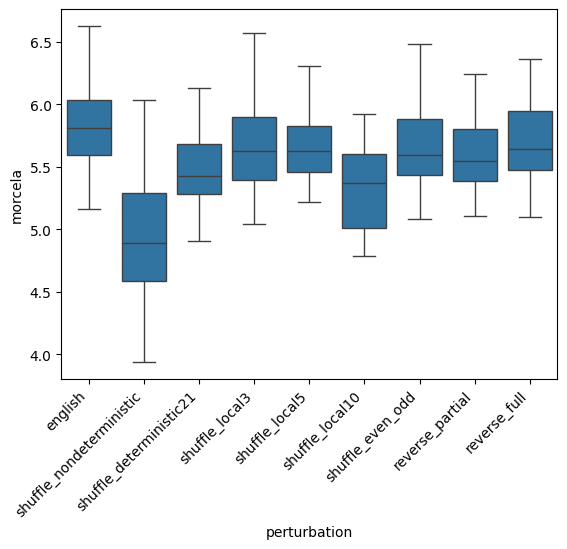

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
df_fixed = df
df_fixed['gen_length'] = df_fixed['generation'].apply(lambda x: len(x.split()))
df_fixed = df_fixed[df_fixed['ntokens'] == 12]
df_fixed.reset_index(inplace=True, drop=True)
sns.boxplot(x='perturbation', y='morcela', data=df_fixed[df_fixed['raw'] == False], showfliers=False)

plt.xticks(rotation=45, ha='right')

In [20]:
df_fixed[df_fixed['perturbation'] == 'shuffle_local10'].sort_values(by='perplexity', ascending=False)[['generation', 'perplexity', 'slor', 'morcela']].head(20)

,generation,perplexity,slor,morcela
173,"in.. the, 2009, to from MinisterHe became 2018",1.972915,6.899776,5.584243
187,"want try just, I you just that? toYou mean",1.827599,6.823092,5.553671
183,"aHow, in and a in a? a hurry about",1.787344,5.837047,4.871129
184,"Now then, trying to be my. the time- -",1.677206,5.915431,4.945064
176,"theWhat, you, are, you? really about they",1.626840,5.888371,4.935326
178,"as, is now, it's not by and and .",1.573976,5.666730,4.790342
186,do you want can't put you in the mouth you .,1.572606,6.922510,5.668395
181,You want a drink.? - I had a good week.,1.510541,7.269087,5.922772
180,"You know that a,, it's not a lot better.",1.482767,6.728681,5.550614
179,"So then, can you look in a list of this.",1.427797,5.977803,5.037121


In [21]:
df_fixed[df_fixed['perturbation'] == 'english'].sort_values(by='perplexity', ascending=False)[['generation', 'perplexity', 'slor', 'morcela']].head(20)

,generation,perplexity,slor,morcela
28,[Tensemble.es and applause] (Gordon),1.706936,8.971963,7.076291
33,He also plays for Derek and Wandaise.,1.637467,8.506118,6.763171
40,"- How could you, by and around here, please?",1.588501,6.205767,5.164365
11,The man must be happy for ever with a friend w...,1.551390,7.371338,5.986214
30,"""The day the sun shone on the moonlit fields.""",1.505972,8.276072,6.627566
8,They must be stopped when the fire happens to-...,1.470998,7.620752,6.176571
24,I am the real son of a gun-sister.,1.456092,6.772322,5.586583
14,The one who can tell us the details and the ot...,1.443592,6.303252,5.261299
9,"""I'm a little girl and then a housekeeper.""",1.416888,7.596346,6.170792
7,The United States is the country's first natio...,1.408674,7.202222,5.897049


In [9]:
df_fixed

,perturbation,generation,morcela,generation_cleaned,hadR,perplexity,slor,raw,gen_length
0,english,-I'd put that one on your finger!,5.953717,-I'd put that one on your finger!,False,1.570714,7.053831,False,7
1,english,"She was born in Los Angeles, California.",6.554421,"She was born in Los Angeles, California.",False,1.296938,7.646502,False,7
2,english,She doesn't know what you're talking about.,6.445852,She doesn't know what you're talking about.,False,1.216702,7.647913,False,7
3,english,Well I've never had to tell you.,6.032131,Well I've never had to tell you.,False,1.414375,6.936633,False,7
4,english,I'll take him for a runny car.,6.020195,I'll take him for a runny car.,False,1.676664,7.177044,False,7
...,...,...,...,...,...,...,...,...,...
481,reverse_full,"If so, you can see this, right?",5.424862,"If so, you can see this, right?",False,1.387102,6.243710,False,7
482,reverse_full,"Thank you, you wanted to see me!",5.818288,"Thank you, you wanted to see me!",False,1.489208,6.652907,False,7
483,reverse_full,- I'll never get it for you.,5.377928,- I'll never get it for you.,False,1.492140,6.023768,False,7
484,reverse_full,"""They told me I'd really be here.",6.143070,"""They told me I'd really be here.",False,1.485057,7.300574,False,7


In [132]:
df_fixed.iloc[225]['generation']

'That makes it hard for people to change, erm, the, even the benefits of government, the more important it will help, a lot of the money, it will help.'

In [ ]:
sub_df = df_fixed[df_fixed['perturbation'] == 'shuffle_deterministic21']
sub_df[sub_df['morcela'] > 5.8].sort_values(by='slor', ascending=True)[['generation', 'slor']].head(20)

,generation,slor
2095,"as but,. that about the not I a we of toAnd t...",5.801848
2777,"'t, the say, canNo that I the say thing.",5.803468
2966,"the number, and, isThe in,,'s it. he "" however...",5.807085
2374,"She I of, the in"" and in theThe to. Kingdom, i...",5.809115
2749,"in """" the the people to. , got the"" twoIn at a...",5.814306
2793,"the with. of he.In's, had a he the "" on on on ...",5.819612
2105,theWe know do the say that. that and's the it ...,5.827725
2363,"and or is the the the are's., his as a of, the...",5.828181
2983,"to, in the're, I donI know do.",5.841736
2994,"for to see it they of for to. of the,, the, th...",5.848409


In [128]:
df_fixed.iloc[100]

perturbation                                english
generation            What are you saying, old man?
morcela                                     6.26822
generation_cleaned    What are you saying, old man?
hadR                                          False
perplexity                                 1.489836
slor                                       7.066479
raw                                           False
gen_length                                        6
Name: 145, dtype: object

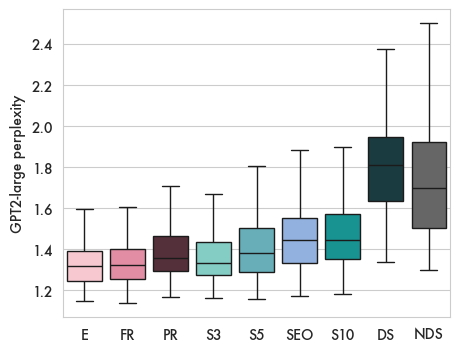

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
#df_fixed = df[df['raw'] == False]

plt.rcParams['font.family'] = 'Futura'
df_fixed = df#[df['raw'] == False]
df_fixed['gen_length'] = df_fixed['generation'].apply(lambda x: len(x.split()))
df_fixed = df_fixed[(df_fixed['ntokens'] >= 10) & (df_fixed['ntokens'] <= 20)]
column_order = [
    'english',
    'reverse_full',
    'reverse_partial',
    'shuffle_local3',
    'shuffle_local5',
    'shuffle_even_odd',
    'shuffle_local10',
    'shuffle_deterministic21',
    'shuffle_nondeterministic',
]

# make aspect ratio wider:
plt.figure(figsize=(5, 4))

sns.boxplot(x='perturbation', y='perplexity', hue='perturbation', data=df_fixed, showfliers=False, order=column_order, hue_order=column_order, legend=False, palette=palette)
# fit labels
# plt.xticks(rotation=30, ha='right')
# set xticks text manually
plt.xticks(ticks=range(len(column_order)), labels=["E", "FR", "PR", "S3", "S5", "SEO", "S10", "DS", "NDS"])
# set font to futura

plt.xlabel("")
plt.ylabel("GPT2-large perplexity")
plt.savefig('perplexity_boxplot.pdf', bbox_inches='tight')

In [275]:
df_fixed['perturbation'].unique()

array(['english', 'shuffle_nondeterministic', 'shuffle_deterministic21',
       'shuffle_local3', 'shuffle_local5', 'shuffle_local10',
       'shuffle_even_odd', 'reverse_partial', 'reverse_full'],
      dtype=object)

In [158]:

#df_fixed[df_fixed['perturbation'] == 'shuffle_deterministic21'].sort_values(by='slor', ascending=True).head(50)
# sentences in shuffle_deterministic with slor greater than the average slor for english sentences in the dataset
english_slor_mean = df_fixed[df_fixed['perturbation'] == 'english']['slor'].mean()
sub_df = df_fixed[df_fixed['perturbation'] == 'shuffle_local10']
sub_df[sub_df['slor'] > english_slor_mean].sort_values(by='perplexity', ascending=True)[['generation', 'perplexity', 'ntokens']].head(20)

,generation,perplexity,ntokens
5669,"""Oh, what have you been looking at?""""We have a...",1.097103,50
5671,"In London he was a professor, for three yearsN...",1.107817,50
5241,Before that he was a member of the national te...,1.111602,46
5935,"'s the is er, there would have that but's what...",1.114677,50
5035,"For instance, but my may be not responsible fo...",1.118365,50
5479,"Your Honor, just the kind of life of heYes?, b...",1.122768,48
5635,"There are a lot of friends., I thinkWhy did yo...",1.126167,36
5819,The people as are the part of the U.The termin...,1.127171,50
5647,"In addition, at the University of a department...",1.128289,49
5775,"Pego Jackson is hired by actor or actorOther, ...",1.129037,48


In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
tokens = tokenizer("him okay we'll, -? see,Okay we'll Okay.", return_tensors='pt')

print(model(tokens['input_ids'],labels=tokens['input_ids']).loss)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor(6.3789, grad_fn=<NllLossBackward0>)


In [12]:
# add the quantiles of slor for english  to df, by ntokens
# make buckets of ntokens and then calculate the quantiles for each bucket
# ntokens are integers
bins = pd.cut(df['ntokens'], bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
df['ntokens_bucket'] = bins
english_slor_quantiles = df[df['perturbation'] == 'english'].groupby('ntokens_bucket')['slor'].quantile([0.25, 0.5, 0.75]).unstack(level=-1)
english_slor_quantiles.columns = ['perplexity_q25', 'perplexity_q50', 'perplexity_q75']
df = df.merge(english_slor_quantiles, on='ntokens_bucket', how='left')

/var/folders/tp/pztldjc90y7b_bcjl31gymqw0000gn/T/ipykernel_87895/2294509766.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  english_slor_quantiles = df[df['perturbation'] == 'english'].groupby('ntokens_bucket')['slor'].quantile([0.25, 0.5, 0.75]).unstack(level=-1)


MergeError: Passing 'suffixes' which cause duplicate columns {'perplexity_q50_x', 'perplexity_q25_x', 'perplexity_q75_x'} is not allowed.

In [14]:

# add the quantiles of slor for english  to df, by ntokens
# make buckets of ntokens and then calculate the quantiles for each bucket
# ntokens are integers
bins = pd.cut(df['ntokens'], bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
df['ntokens_bucket'] = bins
english_slor_quantiles = df[df['perturbation'] == 'english'].groupby('ntokens_bucket')['perplexity'].quantile([0.25, 0.5, 0.75]).unstack(level=-1)
english_slor_quantiles.columns = ['perplexity_q25', 'perplexity_q50', 'perplexity_q75']
df = df.merge(english_slor_quantiles, on='ntokens_bucket', how='left')
df2 = df[df['ntokens_bucket'] == pd.Interval(5, 10)]
total = df2.groupby('perturbation')['perplexity_q75_y'].size()
df2[(df2['perplexity'] < df2['perplexity_q75_y'])].groupby('perturbation').size() / total

# add as a column to df
df['below_perplexity_q75'] = df['perplexity'] < df['perplexity_q75_y']

# plot_df = the proportion of sentences in each perturbation that are below the perplexity_q75_y, by ntokens bucket
plot_df = df.dropna(subset=['ntokens_bucket'])
plot_df = plot_df.groupby(['perturbation', 'ntokens_bucket'])['below_perplexity_q75'].mean().reset_index()
plot_df['plot_position'] = plot_df['ntokens_bucket'].apply(lambda x: x.left + 2.5)
sns.set_style("whitegrid")
ax = sns.lineplot(x='plot_position', y='below_perplexity_q75', hue='perturbation', data=plot_df, palette=palette, hue_order=order)

pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
ax.legend(loc='center right', bbox_to_anchor=(1.6, 0.5))
ax.set_xlabel("Number of generated tokens")
ax.set_ylabel("Proportion with perplexity < 75% of English")

/var/folders/tp/pztldjc90y7b_bcjl31gymqw0000gn/T/ipykernel_87895/2446762919.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  english_slor_quantiles = df[df['perturbation'] == 'english'].groupby('ntokens_bucket')['perplexity'].quantile([0.25, 0.5, 0.75]).unstack(level=-1)


MergeError: Passing 'suffixes' which cause duplicate columns {'perplexity_q50_x', 'perplexity_q25_x', 'perplexity_q75_x'} is not allowed.

                perplexity_q25  perplexity_q50  perplexity_q75
ntokens_bucket                                                
(0, 5]                2.359816        3.347917        4.631284
(5, 10]               1.456889        1.605978        1.765245
(10, 15]              1.302627        1.355708        1.409325
(15, 20]              1.203116        1.228652        1.271401
(20, 25]              1.161974        1.179434        1.200547
hi?????
Index(['perturbation', 'generation', 'morcela', 'generation_cleaned', 'hadR',
       'perplexity', 'slor', 'ntokens', 'raw', 'ntokens_bucket', 'gen_length',
       'perplexity_q25', 'perplexity_q50', 'perplexity_q75'],
      dtype='object')
      perturbation                                         generation  \
0          english                                              Come.   
1          english  They had a daughter of six months, and a son n...   
2          english  The most common symptom of the disease is pneu...   
3          english

/var/folders/tp/pztldjc90y7b_bcjl31gymqw0000gn/T/ipykernel_87895/937700690.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('ntokens_bucket')[metric]
/var/folders/tp/pztldjc90y7b_bcjl31gymqw0000gn/T/ipykernel_87895/937700690.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = df.dropna(subset=['ntokens_bucket']).groupby(['perturbation', 'ntokens_bucket']).agg(
/Users/coleman/Documents/projects/research/impossible-languages/.venv/lib/python3.13/site-packages/statsmodels/stats/proportion.py:282: RuntimeWarning: divide by zero encountered in divide
  denom = 1 + crit2 / nobs_a
/Users/cole

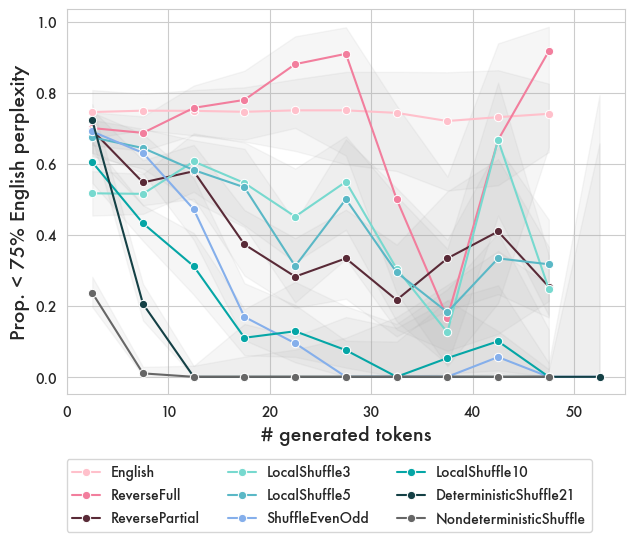

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
save_df = []

def plot_metric_proportion(df, metric='slor', bin_size=5, ci_method='wilson'):
    """
    Plot proportion of sentences below the 75th percentile of English for a given metric,
    binned by number of tokens.
    
    Parameters:
    - df: DataFrame with columns ['ntokens', 'perturbation', metric]
    - metric: metric to use ('slor', 'perplexity', 'morcela', etc.)
    - bin_size: size of the ntokens bins
    - ci_method: method for confidence intervals ('wilson', 'normal', 'jeffreys', etc.)
    """

    column_order = [
        'english',
        'reverse_full',
        'reverse_partial',
        'shuffle_local3',
        'shuffle_local5',
        'shuffle_even_odd',
        'shuffle_local10',
        'shuffle_deterministic21',
        'shuffle_nondeterministic',
    ]
    # Create bins dynamically
    max_tokens = df['ntokens'].max()
    bins = list(range(0, max_tokens + bin_size, bin_size))
    df['ntokens_bucket'] = pd.cut(df['ntokens'], bins=bins)

    # Compute English quantiles for the metric in each bucket
    english_quantiles = (
        df[df['perturbation'] == 'english']
        .groupby('ntokens_bucket')[metric]
        .quantile([0.25, 0.5, 0.75])
        .unstack(level=-1)
    )
    english_quantiles.columns = [f'{metric}_q25', f'{metric}_q50', f'{metric}_q75']
    print(english_quantiles.head())
    
    # Merge back to df
    df = df.merge(english_quantiles, on='ntokens_bucket', how='left')
    print('hi?????')
    print(df.columns)

    
    # Flag sentences below 75th percentile
    df[f'below_{metric}_q75'] = df[metric] < df[f'{metric}_q75']
    print(df)


    # print 5 examples below and above the 75th percentile for each perturbation, in bucks (5, 10] and (20, 25])
    for perturbation in df['perturbation'].unique():
        for bucket in (pd.Interval(10, 15),):
            sub_df = df[(df['perturbation'] == perturbation) & (df['ntokens_bucket'] == bucket)]
            if not sub_df.empty:
                print(f"Perturbation: {perturbation}, Bucket: {bucket}")
                print("Below 75th percentile:")
                print(sub_df[sub_df[f'below_{metric}_q75']].sort_values(by=metric, ascending=True)['generation'].head(5).to_list())
                print("Above 75th percentile:")
                print(sub_df[~sub_df[f'below_{metric}_q75']].sort_values(by=metric, ascending=False)['generation'].head(5).to_list())
                print("\n")
    
    # Group for plotting
    plot_df = df.dropna(subset=['ntokens_bucket']).groupby(['perturbation', 'ntokens_bucket']).agg(
        n=('ntokens', 'size'),
        prop_below=(f'below_{metric}_q75', 'mean')
    ).reset_index()
    
    # Calculate confidence intervals
    ci_low, ci_upp = proportion_confint(
        count=plot_df['prop_below'] * plot_df['n'], 
        nobs=plot_df['n'], 
        method=ci_method
    )
    plot_df['ci_lower'] = ci_low
    plot_df['ci_upper'] = ci_upp
    
    # Position for plotting
    plot_df['plot_position'] = plot_df['ntokens_bucket'].apply(lambda x: x.left + bin_size / 2)
    
    # Plot
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'Futura'
    # turn off borders
    plt.figure(figsize=(8,5))
    ax = sns.lineplot(
        x='plot_position', 
        y='prop_below', 
        hue='perturbation', 
        hue_order=column_order,
        palette=palette,
        data=plot_df, 
        marker='o'
    )
    
    # Add confidence intervals
    for perturbation in plot_df['perturbation'].unique():
        sub_df = plot_df[plot_df['perturbation'] == perturbation]
        ax.fill_between(
            sub_df['plot_position'],
            sub_df['ci_lower'],
            sub_df['ci_upper'],
            alpha=0.1,
            color="#AAAAAA"
        )
        # error bars instead of shaded area:
        # ax.errorbar(
        #     sub_df['plot_position'], 
        #     sub_df['prop_below'], 
        #     yerr=[abs(sub_df['prop_below'] - sub_df['ci_lower']), abs(sub_df['ci_upper'] - sub_df['prop_below'])], 
        #     fmt='none', 
        #     ecolor=palette[column_order.index(perturbation)], 
        #     alpha=0.5
        # )
    
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
    #x.legend(loc='center right', bbox_to_anchor=(1.45, 0.5))
    # Customize legend labels
    handles, labels = ax.get_legend_handles_labels()
    # Create a mapping for nicer legend labels
    label_mapping = {
        'english': 'English',
        'reverse_full': 'ReverseFull',
        'reverse_partial': 'ReversePartial',
        'shuffle_local3': 'LocalShuffle3',
        'shuffle_local5': 'LocalShuffle5',
        'shuffle_even_odd': 'ShuffleEvenOdd',
        'shuffle_local10': 'LocalShuffle10',
        'shuffle_deterministic21': 'DeterministicShuffle21',
        'shuffle_nondeterministic': 'NondeterministicShuffle'
    }
    new_labels = [label_mapping.get(label, label) for label in labels]
    ax.legend(handles, new_labels, loc='upper center', bbox_to_anchor=(0.47, -0.15), ncol=3)

    ax.set_xlabel("# generated tokens")
    ax.set_ylabel(f"Prop. < 75% English {metric}")
    # make xlabel and ylabel bigger
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    #plt.show()
    plt.savefig(f'proportion_below_english_{metric}.pdf', bbox_inches='tight')
    
    return plot_df

# Example usage:
plot_df = plot_metric_proportion(df, metric='perplexity', bin_size=5)

In [49]:
save_df

[]

/var/folders/tp/pztldjc90y7b_bcjl31gymqw0000gn/T/ipykernel_364/3729663981.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = plot_df.groupby(['perturbation', 'ntokens_bucket'])['below_perplexity_q75'].mean().reset_index()


Text(0, 0.5, 'Proportion with perplexity < 75% of English')

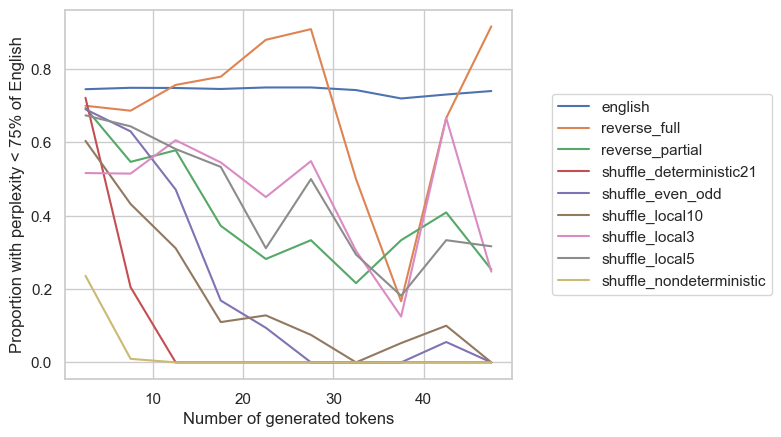

In [186]:
df2 = df[df['ntokens_bucket'] == pd.Interval(5, 10)]
total = df2.groupby('perturbation')['perplexity_q75_y'].size()
df2[(df2['perplexity'] < df2['perplexity_q75_y'])].groupby('perturbation').size() / total

# add as a column to df
df['below_perplexity_q75'] = df['perplexity'] < df['perplexity_q75_y']

# plot_df = the proportion of sentences in each perturbation that are below the perplexity_q75_y, by ntokens bucket
plot_df = df.dropna(subset=['ntokens_bucket'])
plot_df = plot_df.groupby(['perturbation', 'ntokens_bucket'])['below_perplexity_q75'].mean().reset_index()
plot_df['plot_position'] = plot_df['ntokens_bucket'].apply(lambda x: x.left + 2.5)
sns.set_style("whitegrid")
ax = sns.lineplot(x='plot_position', y='below_perplexity_q75', hue='perturbation', data=plot_df)

pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width * 0.9, pos.height])
ax.legend(loc='center right', bbox_to_anchor=(1.6, 0.5))
ax.set_xlabel("Number of generated tokens")
ax.set_ylabel("Proportion with perplexity < 75% of English")

/var/folders/tp/pztldjc90y7b_bcjl31gymqw0000gn/T/ipykernel_364/3201509080.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = df.groupby(['perturbation', 'ntokens_bucket']).size().reset_index(name='count')


Text(0, 0.5, 'Density')

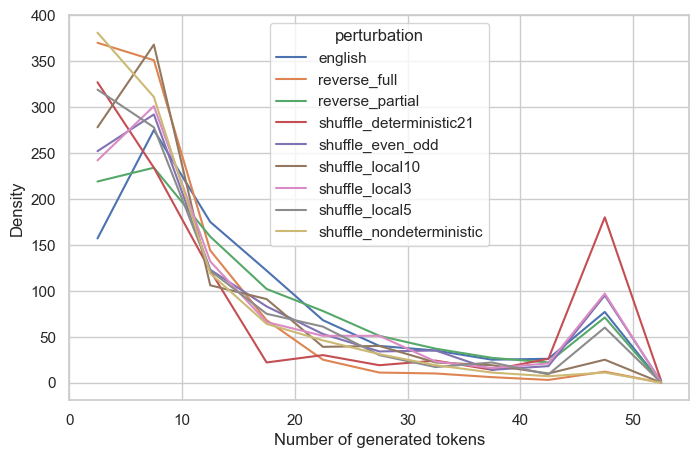

In [257]:
# distribution of lengths by perturbation:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
plot_df = df.groupby(['perturbation', 'ntokens_bucket']).size().reset_index(name='count')
plot_df['ntokens'] = plot_df['ntokens_bucket'].apply(lambda x: x.left + 2.5)
sns.lineplot(data=plot_df, x='ntokens', y='count', hue='perturbation')
plt.xlabel("Number of generated tokens")
plt.ylabel("Density")

Text(0, 0.5, 'Density')

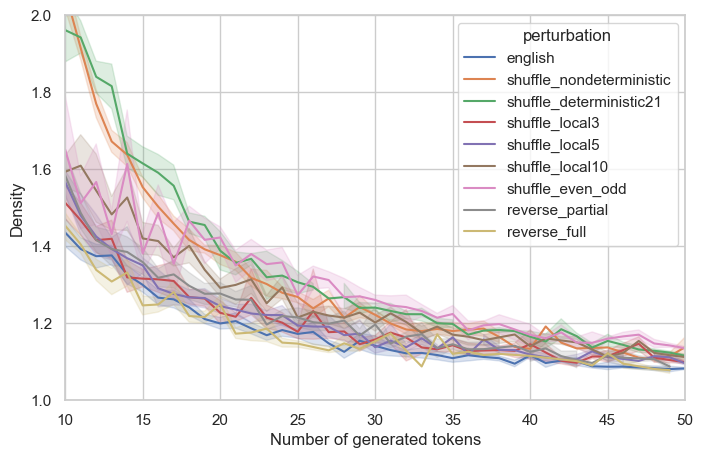

In [264]:
# distribution of lengths by perturbation:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
# plot_df = df.groupby(['perturbation', 'ntokens_bucket']).size().reset_index(name='count')
# plot_df['ntokens'] = plot_df['ntokens_bucket'].apply(lambda x: x.left + 2.5)
sns.lineplot(data=df, x='ntokens', y='perplexity', hue='perturbation')
plt.ylim(1, 2)
plt.xlim(10, 50)
plt.xlabel("Number of generated tokens")
plt.ylabel("Density")

In [244]:
# Drop any existing perplexity quantile columns
#df = df.drop(columns = [0.25, 0.5, 0.75])
cols_to_drop = [col for col in df.columns if 'slor_q' in col]
df = df.drop(columns=cols_to_drop)

# Verify
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['perturbation', 'generation', 'morcela', 'generation_cleaned', 'hadR', 'perplexity', 'slor', 'ntokens', 'raw', 'gen_length', 'morcela_q25', 'morcela_q50', 'morcela_q75', 'ntokens_bucket']


In [197]:
df.columns

Index([        'perturbation',           'generation',              'morcela',
         'generation_cleaned',                 'hadR',           'perplexity',
                       'slor',              'ntokens',                  'raw',
                 'gen_length',             'slor_q25',             'slor_q50',
                   'slor_q75',          'morcela_q25',          'morcela_q50',
                'morcela_q75',     'perplexity_q25_x',     'perplexity_q50_x',
           'perplexity_q75_x',       'ntokens_bucket',     'perplexity_q25_y',
           'perplexity_q50_y',     'perplexity_q75_y', 'below_perplexity_q75',
             'perplexity_q25',       'perplexity_q50',       'perplexity_q75',
                         0.25,                    0.5,                   0.75],
      dtype='object')

In [167]:
sns.lineplot()

0         (0, 5]
1       (45, 50]
2        (5, 10]
3       (25, 30]
4       (20, 25]
          ...   
8986      (0, 5]
8987      (0, 5]
8988      (0, 5]
8989      (0, 5]
8990    (10, 15]
Name: ntokens_bucket, Length: 8991, dtype: category
Categories (10, interval[int64, right]): [(0, 5] < (5, 10] < (10, 15] < (15, 20] ... (30, 35] < (35, 40] < (40, 45] < (45, 50]]

In [161]:
df2[(df2['perplexity'] > df2['perplexity_q75']) & (df2['perturbation'] == 'shuffle_local10')].sort_values(by='perplexity', ascending=True)[['generation', 'perplexity', 'ntokens']].head(20)

,generation,perplexity,ntokens
5027,"So, what's the question I'm looking forHey, fo...",1.218320,20
5493,"Before he was in the city, I think thatI'm goi...",1.227384,20
5738,"And he's going to sit on the big chair, he and...",1.229372,20
5608,"As we've done this, we can gather moreI know o...",1.256079,20
5906,I have a dream so that I haven't seenLydia was...,1.263394,20
5537,"I want her son to you and a second,What do you...",1.263764,20
5399,They need to be the thing that the things that...,1.265201,20
5713,"You don't think he was it out in theWhere´s, y...",1.265336,20
5445,I want to pay for it for the kids!Mhm. had the...,1.267851,20
5571,"John Stephenson was born on 24 January, 1931 a...",1.275313,20


In [166]:
df2

,perturbation,generation,morcela,generation_cleaned,hadR,perplexity,slor,ntokens,raw,gen_length,...,morcela_q25,morcela_q50,morcela_q75,perplexity_q25_x,perplexity_q50_x,perplexity_q75_x,ntokens_bucket,perplexity_q25_y,perplexity_q50_y,perplexity_q75_y


/var/folders/tp/pztldjc90y7b_bcjl31gymqw0000gn/T/ipykernel_364/2516578878.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2[(df2['perplexity'] > df2['perplexity_q75'])][df2['perturbation'] == 'reverse_full'][['generation', 'perplexity', 'ntokens', 'perplexity', 'slor', 'perplexity_q25', 'perplexity_q75']]


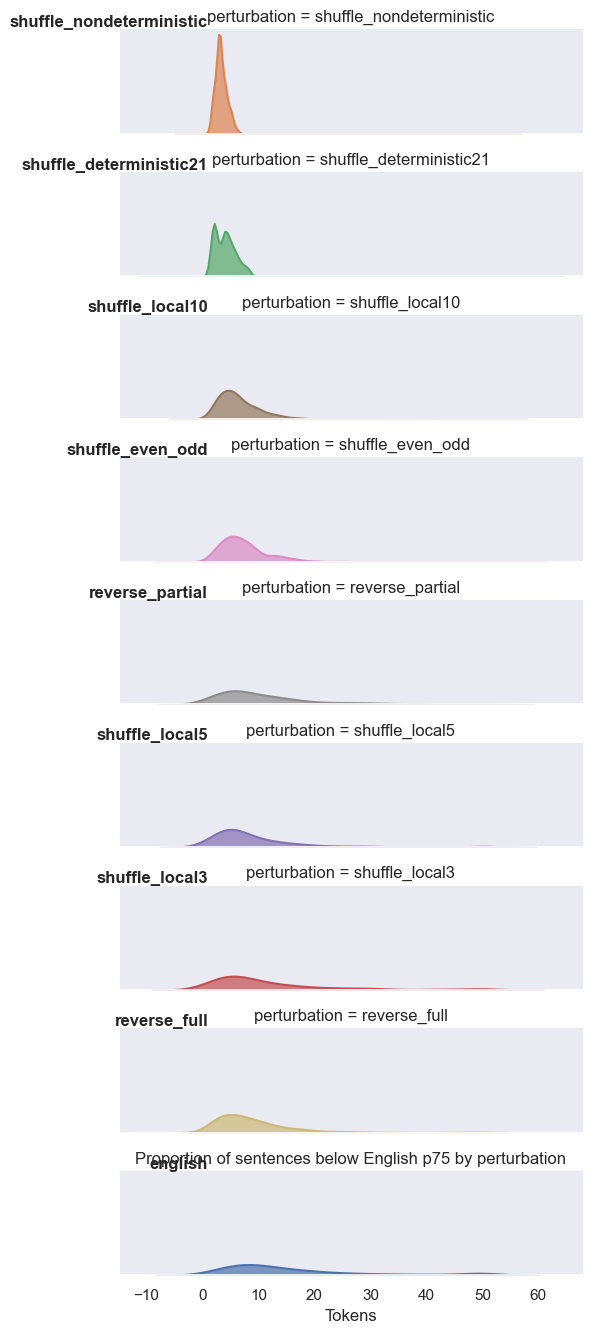

In [157]:
#df2 = df2.reset_index()
df2[(df2['perplexity'] > df2['perplexity_q75'])][df2['perturbation'] == 'reverse_full'][['generation', 'perplexity', 'ntokens', 'perplexity', 'slor', 'perplexity_q25', 'perplexity_q75']]
# plot the proportion of sentences in each perturbation that have perplexity less than the 75th percentile of english sentences, by ntokens using seaborn
df_plot = df.assign(
    below_p75 = df["perplexity"] < df["perplexity_q75"],
    ntok_bin = (df["ntokens"] // 5) * 5,   # bin width = 5
)


perturb_order = df_plot.groupby("perturbation")["below_p75"].mean().sort_values().index

# Vertical spacing for ridge plot
spacing = 1.0
y_positions = {p: i * spacing for i, p in enumerate(perturb_order)}

# Plot each perturbation as a filled KDE
g = sns.FacetGrid(
    df_plot,
    row="perturbation",
    hue="perturbation",
    aspect=4,
    height=1.5,
    row_order=perturb_order
)

# Map KDE to each facet
g.map(
    sns.kdeplot,
    "ntokens",
    weights=df_plot["below_p75"],
    fill=True,
    alpha=0.7,
    linewidth=1.5
)

# Remove y-axis labels/ticks for ridge style
g.set(yticks=[], ylabel="")

# Label each facet clearly on the left
for ax, perturbation in zip(g.axes.flatten(), perturb_order):
    ax.text(
        x=df_plot["ntokens"].min() - 1,
        y=0.5,
        s=perturbation,
        va="center",
        ha="right",
        fontweight="bold"
    )
    sub = df_plot[df_plot["perturbation"] == perturbation]
    # sns.kdeplot(
    #     x=sub["ntokens"],
    #     weights=sub["below_p75"],
    #     fill=True,
    #     alpha=0.7,
    #     linewidth=1.5,
    # )
    # # Shift vertically
    # plt.gca().collections[-1].set_offsets(
    #     [[0, y_positions[perturbation]]] * len(plt.gca().collections[-1].get_paths()[0].vertices)
    # )
    # # Add label
    # plt.text(sub["ntokens"].min() - 1, y_positions[perturbation], perturbation,
    #          va="center", ha="right", fontweight="bold")

# Tweak axes
plt.yticks([])  # hide numeric y-axis
plt.xlabel("Tokens")
plt.title("Proportion of sentences below English p75 by perturbation")
plt.tight_layout()
plt.show()

In [133]:
proportions

perturbation                  
english                   0        True
                          1        True
                          2        True
                          3       False
                          4        True
                                  ...  
shuffle_nondeterministic  1995    False
                          1996    False
                          1997    False
                          1998    False
                          1999    False
Length: 8991, dtype: bool

In [126]:
df2.iloc[113]['generation']

"I mean, yeah cos I'm going to get to be like aa lot of people Yeah."

In [71]:
df2

,perturbation,generation,morcela,generation_cleaned,hadR,perplexity,slor,ntokens,raw,gen_length,slor_q25,slor_q50,slor_q75
1,english,"They had a daughter of six months, and a son n...",5.690751,"They had a daughter of six months, and a son n...",False,1.074427,7.840571,50,False,44,6.989011,7.271657,7.560796
3,english,In 2011 the United States Geological Surveyor ...,6.021444,In 2011 the United States Geological Surveyor ...,False,1.165924,8.066369,27,False,22,6.887587,7.149321,7.352462
4,english,"A man died, and three years later, in the fall...",5.325243,"A man died, and three years later, in the fall...",False,1.193168,6.940752,22,False,18,6.730311,6.974258,7.327669
6,english,He would not accept it any other title of hono...,5.990462,He would not accept it any other title of hono...,False,1.424098,7.446836,13,False,11,6.696640,7.088647,7.349877
7,english,It contains the names of the three rivers that...,5.530684,It contains the names of the three rivers that...,False,1.134359,7.352462,27,False,21,6.887587,7.149321,7.352462
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8978,reverse_full,Is it okay if I don't have a look at this?,5.881931,Is it okay if I don't have a look at this?,False,1.216742,7.223808,13,False,11,6.696640,7.088647,7.349877
8980,reverse_full,"On Sunday night , she got up with them ; she u...",6.079357,"On Sunday night , she got up with them ; she u...",False,1.374195,7.858756,17,False,17,6.901977,7.220233,7.415280
8983,reverse_full,Tell him it's my first time... that I'm even g...,5.693665,Tell him it's my first time... that I'm even g...,False,1.139162,7.587445,27,False,20,6.887587,7.149321,7.352462
8984,reverse_full,"You know, it doesn't take me on, just like thi...",5.264210,"You know, it doesn't take me on, just like thi...",False,1.164305,7.004393,28,False,22,6.705325,6.800839,6.926853


In [169]:
tokens['input_ids']

tensor([[38400,  8788,   356,  1183,    11,   532,    30,   766,    11, 16454,
           356,  1183, 16805,    13]])

In [63]:
df_fixed

,perturbation,generation,morcela,generation_cleaned,hadR,perplexity,slor,ntokens,raw,gen_length,slor_q25,slor_q50,slor_q75
0,english,Come.,9.882695,Come.,False,4.587913,6.503928,2,False,1,5.481136,6.587096,6.587096
1,english,"They had a daughter of six months, and a son n...",5.690751,"They had a daughter of six months, and a son n...",False,1.074427,7.840571,50,False,44,6.989011,7.271657,7.560796
2,english,The most common symptom of the disease is pneu...,6.313675,The most common symptom of the disease is pneu...,False,1.371933,7.510526,10,False,9,6.490010,6.912327,7.231356
3,english,In 2011 the United States Geological Surveyor ...,6.021444,In 2011 the United States Geological Surveyor ...,False,1.165924,8.066369,27,False,22,6.887587,7.149321,7.352462
4,english,"A man died, and three years later, in the fall...",5.325243,"A man died, and three years later, in the fall...",False,1.193168,6.940752,22,False,18,6.730311,6.974258,7.327669
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8986,reverse_full,are you okay ?,8.122928,are you okay ?,False,4.582037,8.131035,4,False,4,6.091594,6.498586,6.841991
8987,reverse_full,"Hey, he.. -",6.681294,"Hey, he.. -",False,3.664622,6.801446,5,False,3,6.112840,6.753798,7.289563
8988,reverse_full,Come on...!,7.613318,Come on...!,False,3.411025,7.274891,4,False,2,6.091594,6.498586,6.841991
8989,reverse_full,Yeah.,9.982063,Yeah.,False,4.000563,6.587096,2,False,1,5.481136,6.587096,6.587096


In [153]:
tokenizer.tokenize("ofOh or certainly yes course course it.")

['of', 'Oh', 'Ġor', 'Ġcertainly', 'Ġyes', 'Ġcourse', 'Ġcourse', 'Ġit', '.']

In [155]:
tokenizer.tokenize("Oh or certainly yes of course course it.")

['Oh', 'Ġor', 'Ġcertainly', 'Ġyes', 'Ġof', 'Ġcourse', 'Ġcourse', 'Ġit', '.']

In [ ]:
df_fixed.iloc[1142]

perturbation                                    shuffle_deterministic21
generation            Ame Cal department,- northse here aand is Bas ...
morcela                                                        5.541231
generation_cleaned    Ame Cal department,- northse here aand is Bas ...
hadR                                                              False
perplexity                                                     1.158889
slor                                                           7.652484
raw                                                               False
gen_length                                                           30
Name: 2015, dtype: object

In [68]:
df_fixed[df_fixed['perturbation'] == 'english'].sort_values(by='slor', ascending=False).head(50)

,perturbation,generation,morcela,generation_cleaned,hadR,perplexity,slor,raw,gen_length
131,english,"“We don't have much time,” answered Fred.",6.978184,"“We don't have much time,” answered Fred.",False,1.349012,8.604662,False,7
952,english,"In 2007, they won the award For Outlawts' Evel...",6.478945,"In 2007, they won the award For Outlawts' Evel...",False,1.432427,8.502469,False,11
423,english,"In 2003, the club won the 2nd place Uggla Reds...",6.343360,"In 2003, the club won the 2nd place Uggla Reds...",False,1.257930,8.384156,False,16
100,english,He was a teacher at the Royal Conservatory Sch...,6.370008,He was a teacher at the Royal Conservatory Sch...,False,1.118055,8.371519,False,14
183,english,"“That's a shame,” said Mr. Chowdler again.",6.570127,"“That's a shame,” said Mr. Chowdler again.",False,1.329849,8.337732,False,7
564,english,"In December 2022, she married Australian-Ameri...",6.447417,"In December 2022, she married Australian-Ameri...",False,1.383917,8.327385,False,9
592,english,“Don't you wanna give me anything back from yo...,6.599150,“Don't you wanna give me anything back from yo...,False,1.423026,8.317310,False,10
126,english,On this year it was named Tropical Depression ...,6.539110,On this year it was named Tropical Depression ...,False,1.368854,8.305807,False,11
709,english,The company was part of the London region to m...,5.983099,The company was part of the London region to m...,False,1.085558,8.276002,False,49
657,english,"The ""communes"" are further divided into three ...",6.333760,"The ""communes"" are further divided into three ...",False,1.195982,8.265564,False,10


/Users/coleman/Documents/projects/research/impossible-languages/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)


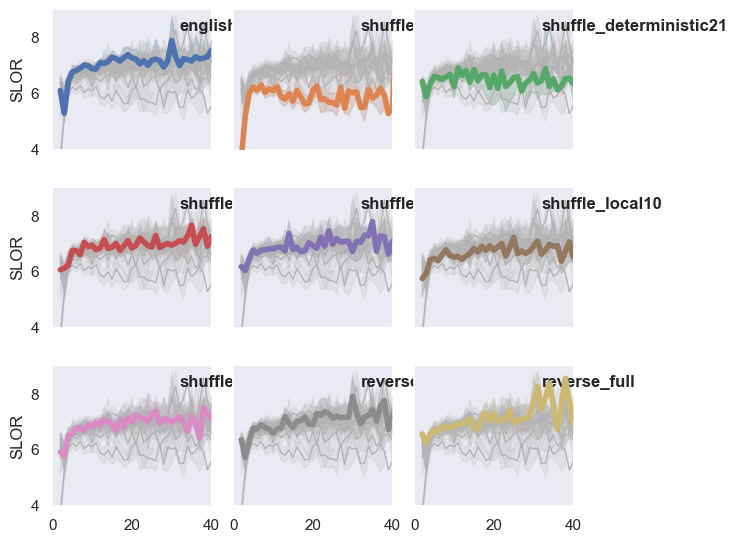

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
df_fixed = df[df['raw'] == False]
df_fixed['gen_length'] = df_fixed['generation'].apply(lambda x: len(x.split()))

# sns.lineplot(x='ntokens', y='slor', hue='perturbation', data=df_fixed)
# sns.set_theme(style="whitegrid")
# sns.displot(data=df_fixed,
#     x="ntokens", hue="perturbation", y="slor",
#     kind="kde", height=6,
#     multiple="fill", clip=(0, None),
#     palette="ch:rot=-.25,hue=1,light=.75",
# )
# plt.ylim(4, 10)
# plt.xlim(1, 30)
sns.set_theme(style="dark")

# Facet: one panel per perturbation
g = sns.relplot(
    data=df_fixed,
    x="ntokens", y="slor",
    col="perturbation", hue="perturbation",
    kind="line",
    
    linewidth=4, zorder=5,
    col_wrap=3, height=2,
    legend=False,
)

# Iterate over each subplot
for perturbation, ax in g.axes_dict.items():

    # Title inside the axes
    ax.text(.8, .85, perturbation, transform=ax.transAxes, fontweight="bold")
    ax.set(ylim=(4, 9), xlim=(1, 35))

    # Background: all perturbations
    sns.lineplot(
        data=df_fixed,
        x="ntokens", y="slor",
        hue="perturbation",      # keep grouping
        palette=[".7"] * df_fixed["perturbation"].nunique(),
        linewidth=1,
        legend=False,
        errorbar=None,
        ax=ax,
    )

# Optional: reduce x tick density (applies to last ax, same as your example)
ax.set_xticks(ax.get_xticks()[::2])

# Clean up titles/labels
g.set_titles("")
g.set_axis_labels("", "SLOR")
g.tight_layout()

In [46]:
df

,perturbation,generation,morcela,generation_cleaned,hadR,perplexity,slor,raw,gen_length
0,english,Come.,7.890272,Come.,False,17.225744,4.223233,False,1
1,english,"They had a daughter of six months, and a son n...",5.514813,"They had a daughter of six months, and a son n...",False,1.070614,7.587341,False,44
2,english,The most common symptom of the disease is pneu...,5.992205,The most common symptom of the disease is pneu...,False,1.336818,7.039461,False,9
3,english,In 2011 the United States Geological Surveyor ...,5.743687,In 2011 the United States Geological Surveyor ...,False,1.143744,7.703087,False,22
4,english,"A man died, and three years later, in the fall...",5.114375,"A man died, and three years later, in the fall...",False,1.188461,6.637378,False,18
...,...,...,...,...,...,...,...,...,...
8987,reverse_full,?🅁 okay youare,6.216458,? okay youare,True,11.341653,5.793893,True,3
8988,reverse_full,"🅁 -.. he,Hey",5.355949,"-.. he,Hey",True,6.338802,5.141349,True,3
8989,reverse_full,🅁!... onCome,6.248460,!... onCome,True,9.677751,5.771357,True,2
8990,reverse_full,.Yeah🅁,3.960923,.Yeah,True,780.755180,0.244151,True,1


In [ ]:
sns.lineplot(x='score', y='perplexity', data=df)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'english'),
  Text(1, 0, 'shuffle_deterministic21'),
  Text(2, 0, 'shuffle_local3'),
  Text(3, 0, 'shuffle_local5'),
  Text(4, 0, 'shuffle_local10'),
  Text(5, 0, 'shuffle_even_odd'),
  Text(6, 0, 'reverse_partial'),
  Text(7, 0, 'reverse_full')])

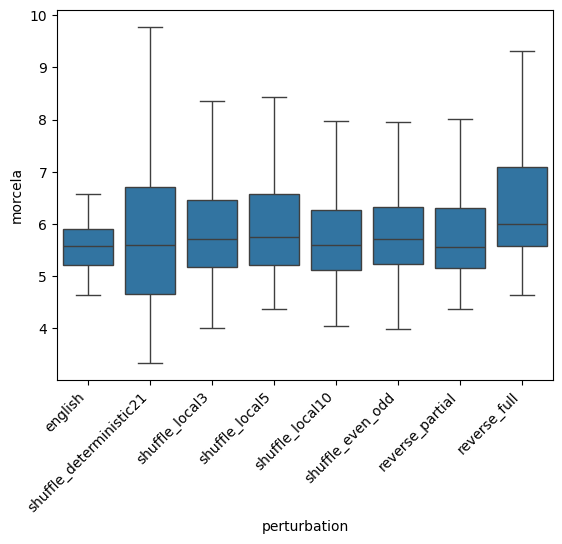

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='perturbation', y='morcela', data=df, showfliers=False)
# fit labels
plt.xticks(rotation=45, ha='right')

In [92]:
import transformers
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer('"Why!, how\'s my health?" said Linda, in great surprise..')

{'input_ids': [1, 5195, 28265, 703, 338, 616, 1535, 1701, 531, 21776, 11, 287, 1049, 5975, 492], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [86]:
tokenizer.decode(18435)

' Hello'